In [2]:
from utils.dependencies import *;

In [55]:
wd_query = Table.read('../WDBinarity/data/2026-03-31_wd_query_final.fits', format='fits')
high_certainty_parallax = wd_query[(wd_query["parallax_over_error"] > 4) & (wd_query["parallax"] > 5)]
mags = high_certainty_parallax["phot_g_mean_mag"] + 5*np.log10(high_certainty_parallax["parallax"]/100)
mag_sort = np.sort(mags)
mag_cdf = np.arange(len(mag_sort))/len(mag_sort)

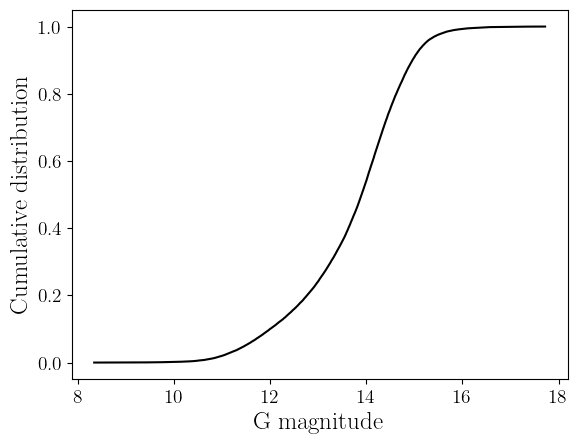

In [57]:
plt.plot(mag_sort, mag_cdf)
plt.xlabel("G magnitude")
plt.ylabel("Cumulative distribution")
plt.show()

In [176]:
FLUX_CUTOFF = 10**(-1.5)
delta_g = 2.5*np.log10(FLUX_CUTOFF)
print(delta_g)

-3.75


In [173]:
mdwarfs = Table.read('./massive_data/2026_06_09_final_table.fits', format='fits')
reduced_mdwarfs = mdwarfs[["solution_type", "parallax", "phot_g_mean_mag", "mass", "q_max"]]

In [187]:
hidable_rate = []
abs_mags = []
for mdwarf in tqdm(reduced_mdwarfs):
    absolute_magnitude = mdwarf["phot_g_mean_mag"] + 5*np.log10(mdwarf["parallax"]/100)
    
    hidable_rate.append(1 - mag_cdf[np.argmin(abs(mag_sort - absolute_magnitude + delta_g))])
    abs_mags.append(absolute_magnitude)
    
hidable_rate = np.array(hidable_rate)
abs_mags = np.array(abs_mags)

  0%|          | 0/418713 [00:00<?, ?it/s]

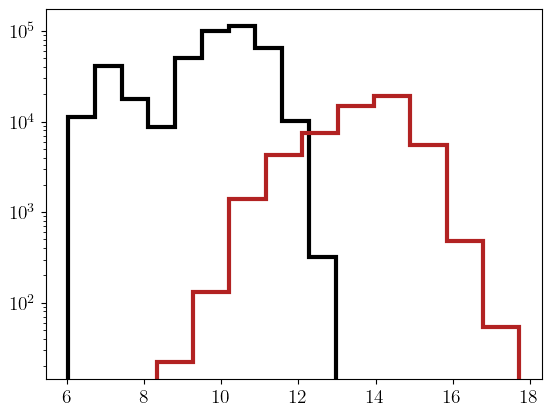

In [186]:
absmags = reduced_mdwarfs["phot_g_mean_mag"] + 5*np.log10(reduced_mdwarfs["parallax"]/100)

plt.hist(absmags, histtype="step", lw=3)
plt.hist(mag_sort, histtype="step", lw=3)
plt.yscale("log")
plt.show()

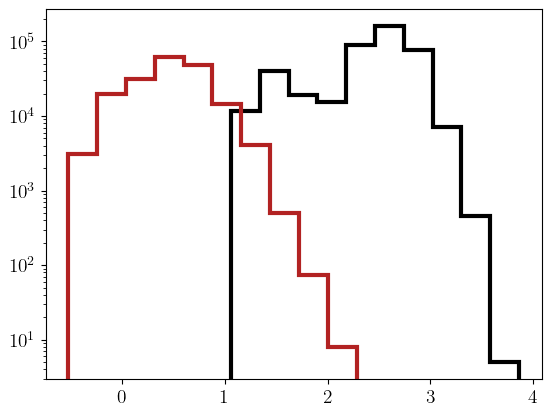

In [68]:
plt.hist(mdwarfs["bp_rp"], histtype="step", lw=3)
plt.hist(wd_query["bp_rp"], histtype="step", lw=3)
plt.yscale("log")
plt.show()

In [79]:
def unresolved_system(MG_ms, bp_rp_ms, MG_wd, MBP_wd, MRP_wd):
    MRP_ms = MG_ms - 0.4 * bp_rp_ms
    MBP_ms = MRP_ms + bp_rp_ms
    MG_comb = -2.5 * np.log10(10**(-0.4 * MG_ms) + 10**(-0.4 * MG_wd))
    MBP_comb = -2.5 * np.log10(10**(-0.4 * MBP_ms) + 10**(-0.4 * MBP_wd))
    MRP_comb = -2.5 * np.log10(10**(-0.4 * MRP_ms) + 10**(-0.4 * MRP_wd))
    return MG_comb, MBP_comb - MRP_comb

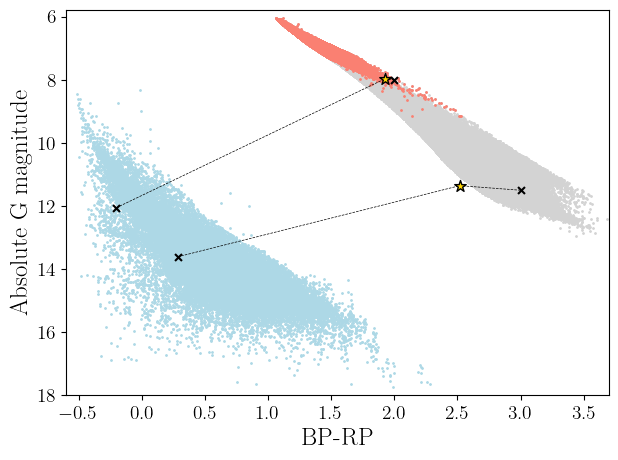

In [133]:
fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(mdwarfs["bp_rp"], absmags, s=1, color="lightgrey")
ax.scatter(mdwarfs[mdwarfs["mass"] > 0.65]["bp_rp"], absmags[mdwarfs["mass"] > 0.65], s=1, color="salmon")
ax.scatter(high_certainty_parallax["bp_rp"], mags, s=1, color="lightblue")

def show_mix(a_s, c_s, a_wd, a_b, a_r, a_c, c_c):
    ax.plot((c_s, c_c), (a_s, a_c), ls="--", lw=0.5, color="k", zorder=1)
    ax.plot((a_b-a_r, c_c), (a_wd, a_c), ls="--", lw=0.5, color="k", zorder=1)
    ax.scatter(c_s, a_s, s=25, marker="x", color="k", zorder=2)
    ax.scatter(a_b-a_r, a_wd, s=25, marker="x", color="k", zorder=2)
    ax.scatter(c_c, a_c, s=75, marker="*", color="gold", edgecolor="k", zorder=3)

def plot_mix(abs_s, bprp_s, abs_wd, abs_bp, abs_rp):
    abs_c, bprp_c = unresolved_system(abs_s, bprp_s, abs_wd, abs_bp, abs_rp)
    show_mix(abs_s, bprp_s, abs_wd, abs_bp, abs_rp, abs_c, bprp_c)

abs_s = 11.5 #mdwarfs[0]["phot_g_mean_mag"] + 5*np.log10(mdwarfs[0]["parallax"]/100)
bprp_s = 3 #mdwarfs[0]["bp_rp"]

indx = 1
abs_wd = high_certainty_parallax[indx]["phot_g_mean_mag"] + 5*np.log10(high_certainty_parallax[indx]["parallax"]/100)
abs_bp = high_certainty_parallax[indx]["bp_g"] + abs_wd
abs_rp = abs_wd - high_certainty_parallax[indx]["g_rp"]

plot_mix(abs_s, bprp_s, abs_wd, abs_bp, abs_rp)

abs_s = 8
bprp_s = 2

indx = 11
abs_wd = high_certainty_parallax[indx]["phot_g_mean_mag"] + 5*np.log10(high_certainty_parallax[indx]["parallax"]/100)-1
abs_bp = high_certainty_parallax[indx]["bp_g"] + abs_wd - 0.3
abs_rp = abs_wd - high_certainty_parallax[indx]["g_rp"] + 0.2

plot_mix(abs_s, bprp_s, abs_wd, abs_bp, abs_rp)

ax.set_xlabel("BP-RP")
ax.set_ylabel("Absolute G magnitude")
ax.invert_yaxis()
ax.set_xlim([-0.6,3.7])
ax.set_ylim([18, 5.8])
plt.show()

## total?

In [61]:
wd_rate = 3.4 # percent, within logp<4.5
wd_rate = wd_rate * (area_in_range((1,8), 4, 1.3) / area_in_range((1,4.5), 4, 1.3)) # extrapolate to all periods
print(f"Estimated (solar-type-primary) contamination rate from WDs: {wd_rate:.2f}%")

Estimated (solar-type-primary) contamination rate from WDs: 5.26%


In [189]:
masses = reduced_mdwarfs["mass"]

rates = []
percs = np.linspace(0, 100, 100)

for i in range(len(percs)-1):
    subsample_mask = (reduced_mdwarfs["mass"] > np.percentile(masses, percs[i])) & (reduced_mdwarfs["mass"] < np.percentile(masses, percs[i+1]))
    rates.append(np.median(hidable_rate[subsample_mask]))
rates = np.array(rates)

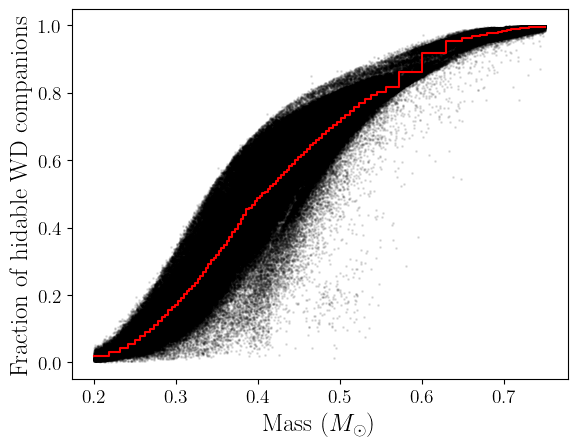

In [190]:
plt.scatter(reduced_mdwarfs["mass"], hidable_rate, s=1, alpha=0.1)

lims = np.array([np.percentile(masses, p) for p in percs])
plt.plot(lims.repeat(2)[1:-1], rates.repeat(2), c="r")
plt.xlabel(r"Mass ($M_\odot$)")
plt.ylabel("Fraction of hidable WD companions")
plt.show()

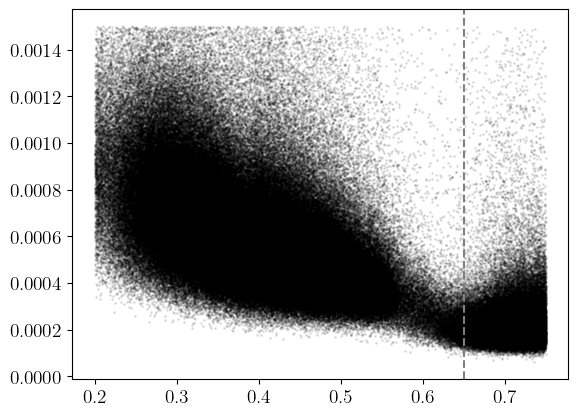

In [228]:
plt.scatter(mdwarfs["mass"], mdwarfs["phot_g_mean_flux_error"]/mdwarfs["phot_g_mean_flux"], s=1, alpha=0.1)
plt.axvline(x=0.65, c="grey", ls="--")
plt.show()

### Monte Carlo

In [ ]:
total_table = Table.read('../BigData/ALL_gaia_source_and_xp_within_200pc.hdf5', path="table")
working_table = Table.read('./data/2026_06_09_gaia_added.fits', format='fits')

In [217]:
isochrone_data = np.genfromtxt('../DR3_planet_candidate_identification/data/isochrones.dat',
                     skip_header=13,
                     skip_footer=1,
                     names=True,
                     dtype=None)

isochrone_mags = isochrone_data["Gmag"]
isochrone_cols = isochrone_data["G_BPmag"] - isochrone_data["G_RPmag"]
edge_mask = (isochrone_cols < 4.5) & (isochrone_mags > 5) & (isochrone_mags < 14) & (isochrone_data["MH"] == -0.3) & (isochrone_data["logAge"] == 9.90001)
edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[edge_mask], isochrone_mags[edge_mask]

def outside_isochrones(target_point):
    return np.interp(x=target_point[0], xp=isochrone_cols, fp=isochrone_mags) < target_point[1]

In [ ]:
abs_s = 11.5 #mdwarfs[0]["phot_g_mean_mag"] + 5*np.log10(mdwarfs[0]["parallax"]/100)
bprp_s = 3 #mdwarfs[0]["bp_rp"]

indx = 1
abs_wd = high_certainty_parallax[indx]["phot_g_mean_mag"] + 5*np.log10(high_certainty_parallax[indx]["parallax"]/100)
abs_bp = high_certainty_parallax[indx]["bp_g"] + abs_wd
abs_rp = abs_wd - high_certainty_parallax[indx]["g_rp"]

abs_c, bprp_c = unresolved_system(abs_s, bprp_s, abs_wd, abs_bp, abs_rp)

outside_isochrones((bprp_c, abs_c))

In [218]:
def check_isochrone():
    rand_mdwarf = np.random.choice(mdwarfs)
    rand_wd = np.random.choice(high_certainty_parallax)
    
    abs_s = rand_mdwarf["phot_g_mean_mag"] + 5*np.log10(rand_mdwarf["parallax"]/100)
    bprp_s = rand_mdwarf["bp_rp"]

    abs_wd = rand_wd["phot_g_mean_mag"] + 5*np.log10(rand_wd["parallax"]/100)
    abs_bp = rand_wd["bp_g"] + abs_wd
    abs_rp = abs_wd - rand_wd["g_rp"]

    abs_c, bprp_c = unresolved_system(abs_s, bprp_s, abs_wd, abs_bp, abs_rp)

    return rand_mdwarf["mass"], outside_isochrones((bprp_c, abs_c))

In [ ]:
masses = []
cut_wds = []

for i in tqdm(range(1000)):
    m, oi = check_isochrone()
    masses.append(m)
    cut_wds.append(oi)
    
masses = np.array(masses)
cut_wds = np.array(cut_wds)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [224]:
rates = []
percs = np.linspace(0, 100, 10)

for i in range(len(percs)-1):
    subsample_mask = (masses > np.percentile(masses, percs[i])) & (masses < np.percentile(masses, percs[i+1]))
    rates.append(np.sum(cut_wds[subsample_mask])/np.sum(subsample_mask))
rates = np.array(rates)

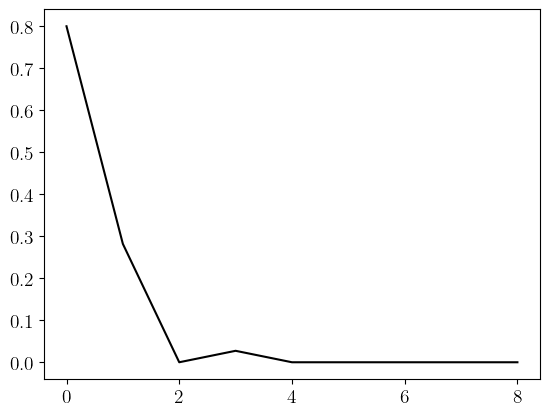

In [225]:
plt.plot(rates)

### Nonsense for intuition

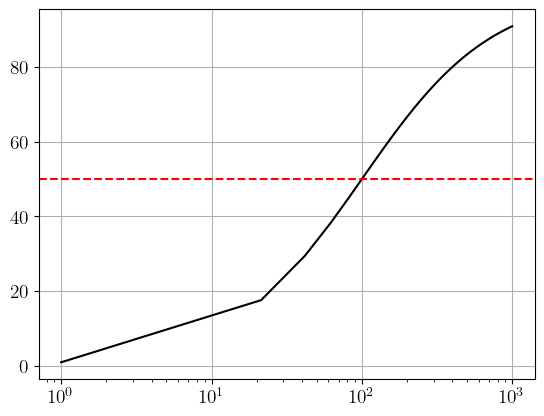

(np.float64(102.93877551020408),
 np.float64(143.71428571428572),
 np.float64(225.26530612244898),
 np.float64(408.7551020408163))

In [39]:
def r(x, bs):
    return bs / (x + bs)

x = 100
bs = np.linspace(1,1000)
plt.plot(bs, r(x, bs)*100)
plt.axhline(50, color='red', linestyle='--')
plt.xscale('log')
plt.grid(True)
plt.show()

bs[np.argmin(np.abs(r(x, bs)*100 - 50))], bs[np.argmin(np.abs(r(x, bs)*100 - 60))], bs[np.argmin(np.abs(r(x, bs)*100 - 70))], bs[np.argmin(np.abs(r(x, bs)*100 - 80))]

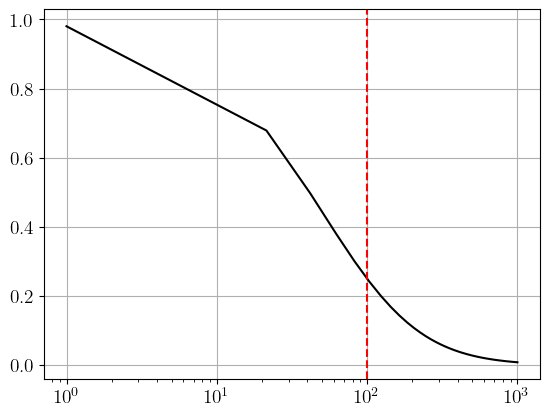

In [33]:
def dr(x, bs):
    return x / ( (x + bs)**2)

x = 100
bs = np.linspace(1,1000)
plt.plot(bs, dr(x, bs)*100)
plt.axvline(x, color='red', linestyle='--')
plt.xscale('log')
plt.grid(True)
plt.show()

- low b: $r \sim b$
- high b: $r \sim 1$

Smooth transition between the two